In [16]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
%run ../ODE/lib.ipynb

In [4]:
from scipy.integrate import solve_ivp
#timestep adattivo

In [230]:
m1 = 0.5
m2 = 0.5
a = 20

In [231]:
# l'integrazione andrà stoppata prima che la descrizione newtoniana fallisca
# per farlo possiamo definire un evento (es. raggiungimento isco) che termina l'integrazione

Part 1: Equations of Motion
The equations of motion for body 1 including Newtonian gravity and the 2.5 PN radiation reaction term are (from here, eq. 339):

$$
\begin{align*}
\boldsymbol{a}_1= & -\frac{G m_2}{r_{12}^2} \boldsymbol{n}_{12} \\
+ & \frac{1}{c^5}\left\{\left[\frac{208 G^3 m_1 m_2^2}{15 r_{12}^4}\left(n_{12} v_{12}\right)-\frac{24 G^3 m_1^2 m_2}{5 r_{12}^4}\left(n_{12} v_{12}\right)+\frac{12 G^2 m_1 m_2}{5 r_{12}^3}\left(n_{12} v_{12}\right) v_{12}^2\right] \boldsymbol{n}_{12}\right. \\
& \left.\quad+\left[\frac{8 G^3 m_1^2 m_2}{5 r_{12}^4}-\frac{32 G^3 m_1 m_2^2}{5 r_{12}^4}-\frac{4 G^2 m_1 m_2}{5 r_{12}^3} v_{12}^2\right] \boldsymbol{v}_{12}\right\} \tag{1}
\end{align*}
$$



The equations for body 2 are obtained by the exchange $1 \leftrightarrow 2$, remembering that $\boldsymbol{n}_{12}$ and $\boldsymbol{v}_{12}$ change sign under this operation ( $\boldsymbol{n}_{21}=-\boldsymbol{n}_{12}$ ).
1. Consider adequate internal units, e.g. when $G=c=M=1$.
2. Reduce both equations of motion to a system of first-order ODEs for the state vector $\left(\boldsymbol{r}_1, \boldsymbol{r}_2, \boldsymbol{v}_1, \boldsymbol{v}_2\right)$ and integrate them numerically using a method of your choice (e.g. RungeKutta 4). Choose initial conditions corresponding to a quasi-circular orbit with a given semi-major axis $a_0$ and eccentricity $e_0$.
3. At each time step, compute the instantaneous orbital elements $a(t)$ and $e(t)$ from the relative coordinate $\boldsymbol{r}=\boldsymbol{r}_1-\boldsymbol{r}_2$ and relative velocity $\boldsymbol{v}=\boldsymbol{v}_1-\boldsymbol{v}_2$, using:

$$
\begin{align*}
& \mathcal{E}=\frac{v^2}{2}-\frac{G M}{r}, \quad a=-\frac{G M}{2 \mathcal{E}},  \tag{2}\\
& \boldsymbol{h}=\boldsymbol{r} \times \boldsymbol{v}, \quad e=\sqrt{1-\frac{h^2}{G M a}}, \tag{3}
\end{align*}
$$

where $M=m_1+m_2, r=|\boldsymbol{r}|, v=|\boldsymbol{v}|, h=|\boldsymbol{h}|$.


4. Be aware that you cannot integrate down to the merger, so you need to set a max time (i.e. the time to merger, see below), or enforce a check on the value of the separation vector (i.e. $r>6$, using appropriate units).

In [232]:
#ignoriamo i termini conservativi in 1/c^3 1/c^4

In [233]:
G = 1
c = 1
M = 1

In [234]:
def unpack(y):
    r1 = np.array([y[0],y[2],y[4]])
    v1 = np.array([y[1],y[3],y[5]])
    r2 = np.array([y[6],y[8],y[10]])
    v2 = np.array([y[7],y[9],y[11]])
    return r1,v1,r2,v2

In [235]:
def f_prime(t, y):
    
    r1 = np.array([y[0],y[2],y[4]])
    v1 = np.array([y[1],y[3],y[5]])
    r2 = np.array([y[6],y[8],y[10]])
    v2 = np.array([y[7],y[9],y[11]])
    
    vec_r12 = r1-r2
    r12 = np.sqrt(np.dot(vec_r12,vec_r12))
    n12 = vec_r12/r12

    vec_v12 = v1-v2
    v12 = np.sqrt(np.dot(vec_v12,vec_v12))
    
    
    a1 = ( -G*m2/r12**2*n12 
          + 1/c**5 * ( ( 208*G**3*m1*m2**2/(15*r12**4)*np.dot(n12,vec_v12) - 24*G**3*m1**2*m2/(5*r12**4)*np.dot(n12,vec_v12) + 12*G**2*m1*m2/(5*r12**3)*np.dot(n12,vec_v12)*v12**2 ) * n12
                    + ( 8*G**3*m1**2*m2/(5*r12**4) - 32*G**3*m1*m2**2/(5*r12**4) - 4*G**2*m1*m2/(5*r12**3)*v12**2 ) * vec_v12 ) ) 

    a2 = ( -G*m2/r12**2* (-n12)
          + 1/c**5 * ( ( 208*G**3*m1*m2**2/(15*r12**4)*np.dot(-n12,-vec_v12) - 24*G**3*m1**2*m2/(5*r12**4)*np.dot(-n12,-vec_v12) + 12*G**2*m1*m2/(5*r12**3)*np.dot(-n12,-vec_v12)*v12**2 ) * (-n12)
                    + ( 8*G**3*m1**2*m2/(5*r12**4) - 32*G**3*m1*m2**2/(5*r12**4) - 4*G**2*m1*m2/(5*r12**3)*v12**2 ) * (-vec_v12) ) ) 

    return v1[0], a1[0], v1[1], a1[1], v1[2], a1[2], v2[0], a2[0], v2[1], a2[1], v2[2], a2[2]

In [236]:
h = 0.01
tf = 2900

t_span =  [0,tf]
e = 0 
vy_0 = m2/M * np.sqrt(G*M/a*(e+1)/(-e+1))
y0 = [-a/2,0,0,vy_0,0,0,a/2,0,0,-vy_0,0,0]

In [237]:
t_ev = np.linspace(0,tf,1000)

sol = solve_ivp(f_prime, t_span, y0, t_eval=t_ev)

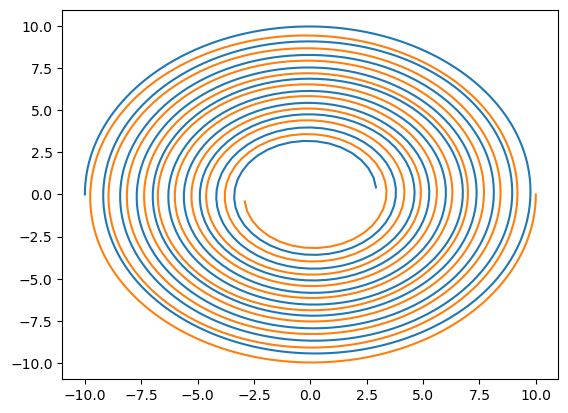

In [238]:
plt.plot(sol['y'][0], sol['y'][2])
plt.plot(sol['y'][6], sol['y'][8])

In [239]:
def eps(y):
    r1,v1,r2,v2 = unpack(y)
    vv = []
    r = []
    for i in range(len(r1[0,:])):
        vv = np.append(vv,np.dot(v1[:,i]-v2[:,i],v1[:,i]-v2[:,i])) #qui calcola il prodotto tra matrici, cambiare
        r = np.append(r, np.sqrt(np.dot(r1[:,i]-r2[:,i],r1[:,i]-r2[:,i])))
    
    return vv/2 - G*M/r

def a_t(y):
    return - G*M/(2*eps(y))

def e_t(y):
    r1,v1,r2,v2 = unpack(y)
    r = r1-r2
    v = v1-v2
    h_t = []
    for i in range(len(v)):
        h_t = np.append(h_t, np.cross(r[:,i],v[:,i]))
    
    return np.sqrt(1 - np.linalg.norm(h_t) / (G*M*a_t(y)))

Text(0, 0.5, '$\\epsilon$(t) [IU]')

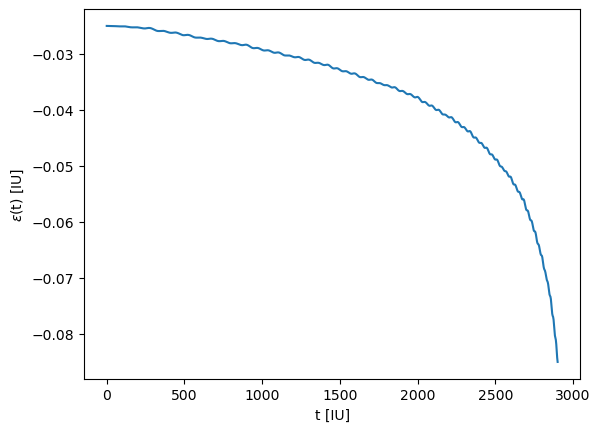

In [240]:
plt.plot(sol['t'],eps(sol['y']))
plt.xlabel('t [IU]')
plt.ylabel(r'$\epsilon$(t) [IU]')

Text(0, 0.5, 'a(t) [IU]')

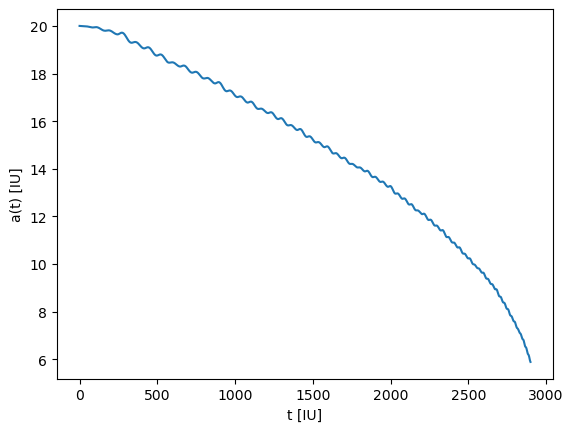

In [241]:
plt.plot(sol['t'],a_t(sol['y']))
plt.xlabel('t [IU]')
plt.ylabel(r'a(t) [IU]')

/tmp/ipykernel_60612/4056163905.py:22: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1 - np.linalg.norm(h_t) / (G*M*a_t(y)))


Text(0, 0.5, 'e(t)')

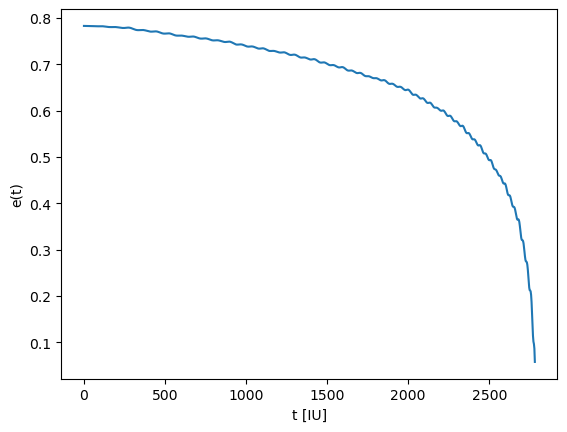

In [242]:
plt.plot(sol['t'],e_t(sol['y']))
plt.xlabel('t [IU]')
plt.ylabel(r'e(t)')